<a href="https://colab.research.google.com/github/2000030914/2000030914/blob/main/CP2_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =========================
# IMPORTS
# =========================
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize

In [2]:
# =========================
# DATASET
# =========================
base_path = "/content/drive/MyDrive/AnnotatedUltrasoundLiver_Dataset"
classes = ['Benign', 'Malignant', 'Normal']

filepaths, labels = [], []

for label in classes:
    folder = os.path.join(base_path, label, "image")
    for file in os.listdir(folder):
        filepaths.append(os.path.join(folder, file))
        labels.append(label)

df = pd.DataFrame({'filename': filepaths, 'class': labels})

In [3]:

# =========================
# TRAIN / VAL / TEST SPLIT
# =========================
train_df, temp_df = train_test_split(
    df, test_size=0.3, stratify=df['class'], random_state=42
)

val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['class'], random_state=42
)

# GENERATORS


In [4]:

IMG_SIZE = 224
BATCH_SIZE = 16

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    train_df, x_col='filename', y_col='class',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='sparse'
)

val_generator = val_datagen.flow_from_dataframe(
    val_df, x_col='filename', y_col='class',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=False
)

test_generator = test_datagen.flow_from_dataframe(
    test_df, x_col='filename', y_col='class',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=False
)


Found 514 validated image filenames belonging to 3 classes.
Found 110 validated image filenames belonging to 3 classes.
Found 111 validated image filenames belonging to 3 classes.


# MODEL: MobileNetV2

In [5]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(3, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# TRAINING

In [8]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15
)

Epoch 1/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - accuracy: 0.5817 - loss: 1.0906 - val_accuracy: 0.7182 - val_loss: 0.6553
Epoch 2/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.6012 - loss: 1.0152 - val_accuracy: 0.7273 - val_loss: 0.6845
Epoch 3/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.5992 - loss: 1.0168 - val_accuracy: 0.7364 - val_loss: 0.7080
Epoch 4/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.6031 - loss: 0.9410 - val_accuracy: 0.7091 - val_loss: 0.7283
Epoch 5/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.6401 - loss: 0.8782 - val_accuracy: 0.7091 - val_loss: 0.7245
Epoch 6/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.6907 - loss: 0.7820 - val_accuracy: 0.7182 - val_loss: 0.7243
Epoch 7/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.6712 - loss: 0.8268 - val_accuracy: 0.7273 - val_loss: 0.7260
Epoch 8/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.6537 - loss: 0.8940 - val_accuracy: 0.7364 - val_loss:

# FINE-TUNING


In [10]:
base_model.trainable = True

for layer in base_model.layers[:-50]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15
)

Epoch 1/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.7821 - loss: 0.4972 - val_accuracy: 0.7727 - val_loss: 0.6339
Epoch 2/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.7840 - loss: 0.4875 - val_accuracy: 0.7545 - val_loss: 0.6420
Epoch 3/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.7821 - loss: 0.5295 - val_accuracy: 0.7636 - val_loss: 0.6371
Epoch 4/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.8093 - loss: 0.4578 - val_accuracy: 0.7727 - val_loss: 0.6246
Epoch 5/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.8016 - loss: 0.4743 - val_accuracy: 0.7818 - val_loss: 0.6192
Epoch 6/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.7840 - loss: 0.4607 - val_accuracy: 0.7727 - val_loss: 0.6198
Epoch 7/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.8210 - loss: 0.4669 - val_accuracy: 0.7818 - val_loss: 0.6213
Epoch 8/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.8093 - loss: 0.4325 - val_accuracy: 0.7909 - val_loss:

# FINAL TESTING


In [11]:
test_loss, test_acc = model.evaluate(test_generator)
print("Final Test Accuracy:", test_acc)

7/7 ━━━━━━━━━━━━━━━━━━━━ 25s 4s/step - accuracy: 0.7838 - loss: 0.5265
Final Test Accuracy: 0.7837837934494019


In [12]:
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes

7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 871ms/step


# VISUALIZATION

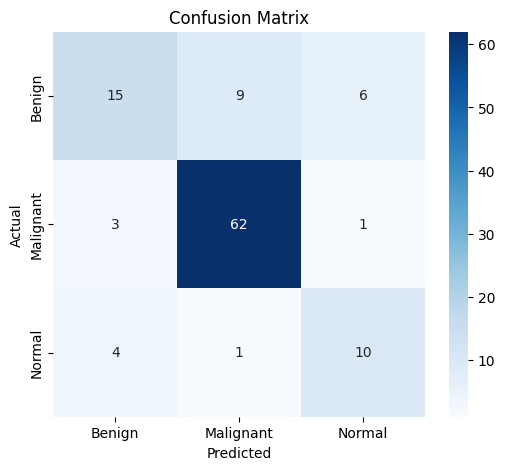


Classification Report:

              precision    recall  f1-score   support

      Benign       0.68      0.50      0.58        30
   Malignant       0.86      0.94      0.90        66
      Normal       0.59      0.67      0.62        15

    accuracy                           0.78       111
   macro avg       0.71      0.70      0.70       111
weighted avg       0.78      0.78      0.77       111



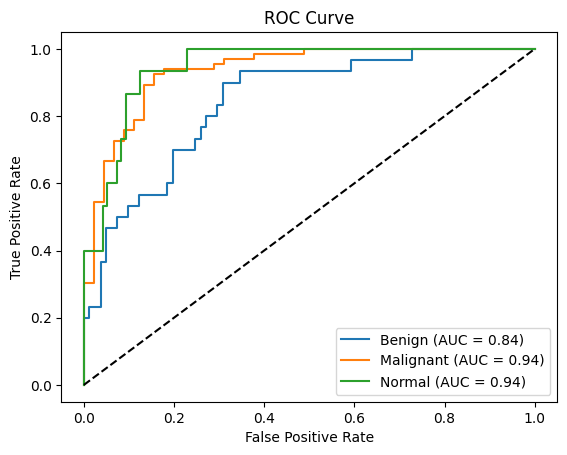

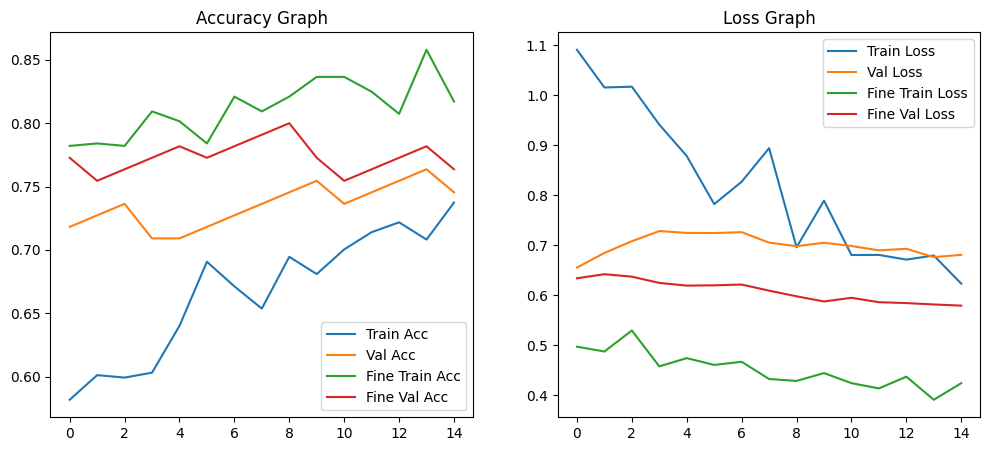

Model saved successfully!


In [13]:

# =========================
# CONFUSION MATRIX
# =========================

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# =========================
# CLASSIFICATION REPORT
# =========================
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=classes))

# =========================
# ROC CURVE
# =========================
y_true_bin = label_binarize(y_true, classes=[0,1,2])

plt.figure()

for i in range(3):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{classes[i]} (AUC = {roc_auc:.2f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# =========================
# ACCURACY & LOSS GRAPHS
# =========================
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.plot(history_fine.history['accuracy'], label='Fine Train Acc')
plt.plot(history_fine.history['val_accuracy'], label='Fine Val Acc')
plt.legend()
plt.title("Accuracy Graph")

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.plot(history_fine.history['loss'], label='Fine Train Loss')
plt.plot(history_fine.history['val_loss'], label='Fine Val Loss')
plt.legend()
plt.title("Loss Graph")

plt.show()

# =========================
# SAVE MODEL
# =========================
model.save("liver_model_final.h5")
print("Model saved successfully!")

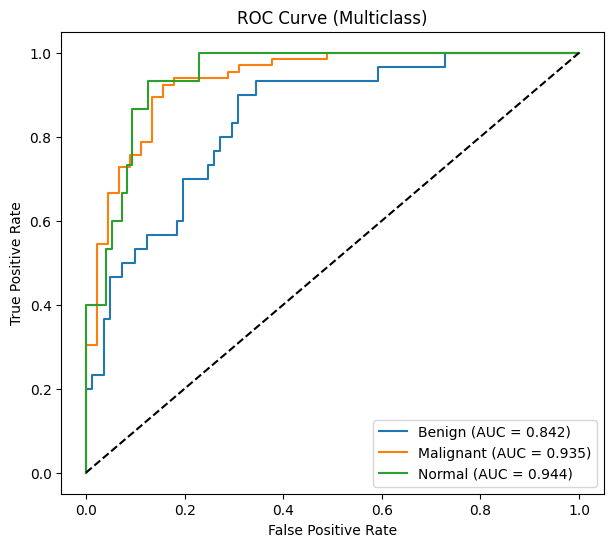

In [14]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_true_bin = label_binarize(y_true, classes=[0,1,2])

plt.figure(figsize=(7,6))

for i in range(3):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'{classes[i]} (AUC = {roc_auc:.3f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Multiclass)')
plt.legend()
plt.show()

In [43]:
class_correct = {c:0 for c in classes}
class_total = {c:0 for c in classes}

results_df = pd.DataFrame({'Actual': [classes[i] for i in y_true], 'Predicted': [classes[i] for i in y_pred_classes]})

for i in range(len(results_df)):
    actual = results_df.iloc[i]['Actual']
    pred = results_df.iloc[i]['Predicted']

    class_total[actual] += 1
    if actual == pred:
        class_correct[actual] += 1

for c in classes:
    print(f"{c} Accuracy: {class_correct[c] / class_total[c]:.2f}")

Benign Accuracy: 0.50
Malignant Accuracy: 0.94
Normal Accuracy: 0.67


# TESTING

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

def predict_image(img_path):
    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    predicted_class = classes[np.argmax(prediction)]
    confidence = np.max(prediction)

    plt.imshow(img)
    plt.title(f"Predicted: {predicted_class} ({confidence:.2f})")
    plt.axis('off')
    plt.show()

    return predicted_class, confidence

In [22]:
def check_image_from_testset(index):
    img_path = test_df.iloc[index]['filename']
    actual = test_df.iloc[index]['class']

    predicted, conf = predict_image(img_path)

    print("Actual Label   :", actual)
    print("Predicted Label:", predicted)
    print("Confidence     :", conf)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step


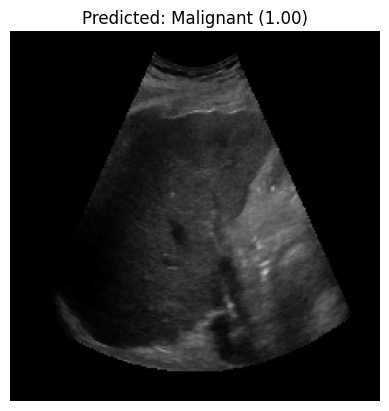

Actual Label   : Malignant
Predicted Label: Malignant
Confidence     : 0.999153


In [23]:
check_image_from_testset(10)

In [30]:
import random
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
def predict_image_clean(img_path):
    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    preds = model.predict(img_array, verbose=0)[0]

    predicted_class = classes[np.argmax(preds)]
    confidence = np.max(preds)

    print("\n--- Prediction Details ---")
    for i, prob in enumerate(preds):
        print(f"{classes[i]} : {prob:.4f}")

    print("\nFinal Prediction :", predicted_class)
    print("Confidence       :", round(confidence, 4))

    plt.imshow(img)
    plt.title(f"{predicted_class} ({confidence:.2f})")
    plt.axis('off')
    plt.show()

    return predicted_class, confidence


In [31]:
def check_image_from_testset(index):
    img_path = test_df.iloc[index]['filename']
    actual = test_df.iloc[index]['class']

    predicted, conf = predict_image_clean(img_path)

    print("\n--- Comparison ---")
    print("Actual Label    :", actual)
    print("Predicted Label :", predicted)
    print("Confidence      :", round(conf, 4))

    if actual == predicted:
        print("Result          : ✅ CORRECT")
    else:
        print("Result          : ❌ WRONG")

In [34]:
def test_multiple_images(n=5):
    print(f"\nTesting {n} random images...\n")

    indices = random.sample(range(len(test_df)), n)

    for i in indices:
        print("="*40)
        check_image_from_testset(i)


Testing 5 random images...


--- Prediction Details ---
Benign : 0.9055
Malignant : 0.0284
Normal : 0.0661

Final Prediction : Benign
Confidence       : 0.9055


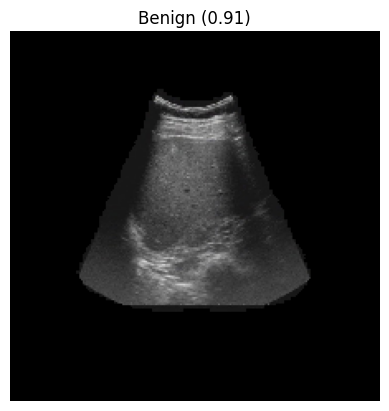


--- Comparison ---
Actual Label    : Benign
Predicted Label : Benign
Confidence      : 0.9055
Result          : ✅ CORRECT

--- Prediction Details ---
Benign : 0.0003
Malignant : 0.9992
Normal : 0.0006

Final Prediction : Malignant
Confidence       : 0.9992


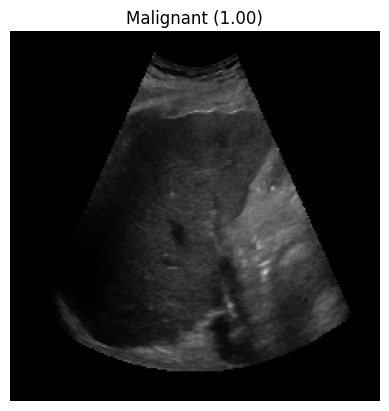


--- Comparison ---
Actual Label    : Malignant
Predicted Label : Malignant
Confidence      : 0.9992
Result          : ✅ CORRECT

--- Prediction Details ---
Benign : 0.4768
Malignant : 0.5163
Normal : 0.0069

Final Prediction : Malignant
Confidence       : 0.5163


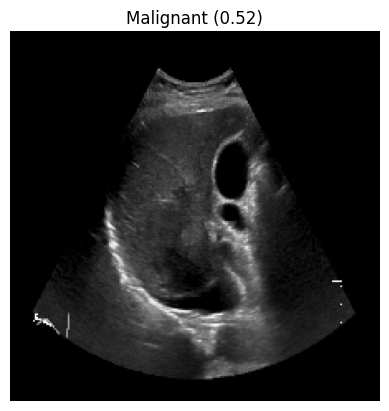


--- Comparison ---
Actual Label    : Malignant
Predicted Label : Malignant
Confidence      : 0.5163
Result          : ✅ CORRECT

--- Prediction Details ---
Benign : 0.0006
Malignant : 0.9992
Normal : 0.0002

Final Prediction : Malignant
Confidence       : 0.9992


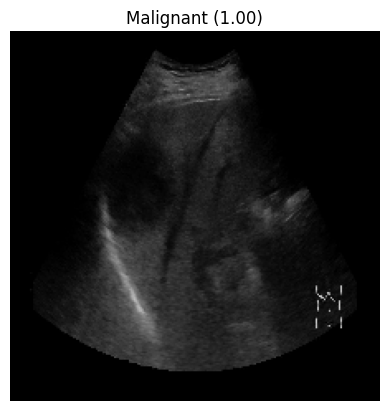


--- Comparison ---
Actual Label    : Malignant
Predicted Label : Malignant
Confidence      : 0.9992
Result          : ✅ CORRECT

--- Prediction Details ---
Benign : 0.0002
Malignant : 0.9998
Normal : 0.0000

Final Prediction : Malignant
Confidence       : 0.9998


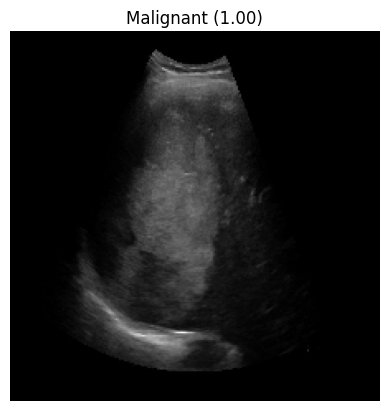


--- Comparison ---
Actual Label    : Malignant
Predicted Label : Malignant
Confidence      : 0.9998
Result          : ✅ CORRECT


In [41]:
test_multiple_images(5)